# 다층 퍼셉트론으로 클래스 모델 구성 및 하이퍼파라미터 최적화

- 목차
1. 라이브러리 import
2. 데이터 준비
    - 학습/검증/테스트 데이터 분리
    - 데이터 표준화
    - Tensor 형태로 데이터 변환
3. 미니배치 준비
4. 모델 준비
5. 학습 및 평가 함수(+Early Stopping)
6. Optuna 활용하여 하이퍼파라미터 최적화
7. 최적의 파라미터로 재학습
8. 시각화

## 1. 라이브러리 import

In [94]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt

# 데이터, 데이터 분리, 스케일링, 지표
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay


# 텐서 조작 및 pytorch 기본, 레이어 구성, 최적화함수, 배치데이터셋 구성
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import TensorDataset, DataLoader


# 기타 라이브러리
import optuna                       # 최적화
import warnings                     # 경고 메세지 제어
warnings.filterwarnings('ignore')   # 경고 메세지 무시
from tqdm import tqdm               # 프로그레스 바


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False




## 2. 데이터 준비

In [95]:
cancer = load_breast_cancer()
X= cancer.data
y= cancer.target

print(X.shape, y.shape)

(569, 30) (569,)


In [96]:
# test 데이터 분리 (최종 성능 평가용)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, 
    test_size= 0.2,
    random_state= 42,
    stratify= y         # 클래스 비율 유지하면서 분할
)

In [97]:
# train/ test 데이터 분리 (하이퍼파라미터 최적화용)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size= 0.25,        # 75 : 25
    random_state= 42,
    stratify= y_trainval         # 클래스 비율 유지하면서 분할
)


print(X_train.shape, X_val.shape, X_test.shape)     # 최종비율 6: 2: 2


(341, 30) (114, 30) (114, 30)


In [98]:
# 입력데이터 표준화
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)     

(341, 30) (114, 30) (114, 30)


In [99]:
# X_train, y_train, X_val, y_val, X_test, y_test 데이터 Tensor형태로 변환(데이터타입은 float)

X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train ).float().reshape(-1,1)
X_val_t = torch.tensor(X_val).float()

y_val_t = torch.tensor(y_val).float().reshape(-1,1)

X_test_t = torch.tensor( X_test).float()
y_test_t = torch.tensor( y_test).float().reshape(-1,1)


print(X_train_t.shape,y_train_t.shape, X_val_t.shape, y_val_t.shape,X_test_t.shape,y_test_t.shape)

torch.Size([341, 30]) torch.Size([341, 1]) torch.Size([114, 30]) torch.Size([114, 1]) torch.Size([114, 30]) torch.Size([114, 1])


## 3. 미니배치 준비

In [100]:
# 미니배치 : 학습/검증/테스트용 DataLoader 를 생성하는 함수
def make_loaders(batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),    # 학습용 입력(x)와 정답(y)를 묶어 전달
        batch_size= batch_size,                 # 미니배치 크기
        shuffle= True                           # 학습용 데이터는 섞어서 일반화 성능 향상
    )
        
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size= batch_size,
        shuffle= False                          # 검증용 데이터는 순서 고정
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size= batch_size,
        shuffle= False                          # 테스트 데이터도 순서 고정
    )
    
    return train_loader, val_loader, test_loader    # 3 종류의 DataLoader 반환


미니 배치용 데이터로더 만들때 학습 데이터는 shuffle,  
검증/ 테스트 데이터는 고정된 순서로 로딩시키는 것이 기본 원칙이다.

## 4. 모델 준비

In [101]:
# 다중 퍼셉트론 이진분류 모델 (출력은 logit 1개)
class MLP(nn.Module):
    
    def __init__(self, input_dim, hidden_dim1 = 64, hidden_dim2 = 32, dropout_p = 0.0):
        super().__init__()            # nn.Module 초기화 
        
        self.fc1 = nn.Linear(input_dim, hidden_dim1)    # 입력 -> 첫번째 은닉층
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)  # 첫번쨰 은닉층 -> 두 번째 은닉층
        self.fc_out = nn.Linear(hidden_dim2, 1)         # 출력층 : 두번째 은닉층 -> logit 값 1개 출력
        
        self.act = nn.ReLU()        # 활성화 함수
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()    # Dropout 사용 또는 없을 시 통과
        
    def forward(self, X):
        X = self.act(self.fc1(X))   # 첫 번째 은닉층 + ReLU
        X = self.dropout(X)         # Dropout 적용 (선택)
        
        X = self.act(self.fc2(X))   # 두번째 은닉층 + ReLU
        X = self.dropout(X)         # Dropout 적용 (선택)
        
        X = self.fc_out(X)          # 출력층 (batch_size, 1) 형태로 출력
        
        return X

## 5. 학습 및 평가 함수

In [102]:
criterion = nn.BCEWithLogitsLoss()


# 학습 함수
def train_one_epoch(model, loader, optimizer):
    model.train()       # 학습모드 전환
    losses = []         # 배치별 loss 를 저장할 리스트
    
    for xb, yb in loader:   # 미니배치 단위로 (입력, 정답) 반복
        logits = model(xb)  # 순전파 : 모델 출력(logit ) 계산
        loss = criterion(logits, yb)    # 예측(logit)과 정답(0/1)으로 BCE 손실 계산
        
        optimizer.zero_grad()       # 이전 step의 기울기 초기화
        loss.backward()             # 역전파 : 현재 loss 기준으로 기울기 계산
        optimizer.step()            # 계산된 기울기로 파라미터(가중치/ 편향) 업데이트
        
        losses.append(loss.item())  # 파이썬 숫자형태로 loss 값 저장
        
    
    return float(np.mean(losses))   # 1 epoch 동안 평균 train loss 변환
        
        

In [103]:
# 평가 함수

@torch.no_grad()    # 데코레이터 방식(함수 안에서 with torch.no_grad() : 구문 사용과 같음)
def evaluate(model, loader):
    model.eval()        # 평가모드로 전환(dropout 비활성화, batchNorm은 고정 통계 사용: 비활성화)
    losses = []         # 배치별 loss
    y_true_all = []     # 실제 정답
    y_prob_all = []     # 예측 확률
    
    # 미니배치 단위로 반복
    for xb, yb in loader:   
        logits = model(xb)              # 순전파: 모델출력(logit) 계산
        loss = criterion(logits, yb)    # 검증/테스트 loss 계산
        prob = torch.sigmoid(logits)    # logit -> 확률(0 ~ 1) 변환 (시각화/ 평가지표)
        
        losses.append(loss.item())              # loss 기록
        y_true_all.append(yb.cpu().numpy())     # 정답을 numpy 형태로 변환
        y_prob_all.append(prob.cpu().numpy())   # 예측 확률도 numpy 형태로 변환
        
    y_true = np.vstack(y_true_all).ravel()      # (N, 1) -> (N, ) 형태로 변환
    y_prob = np.vstack(y_prob_all).ravel()      # (N, 1) -> (N, ) 형태로 변환
    y_pred = (y_prob > 0.5).astype(int)         # 임계값 0.5 기준으로 클래스 (0/ 1) 결정
    
    acc = accuracy_score(y_true, y_pred)        # 정확도 계산
    auc = roc_auc_score(y_true, y_prob)         # ROC - AUC 계산(확률 기반)
    return float(np.mean(losses)), acc, auc, y_true, y_prob     # 평균 Loss, acc, auc, 정답/확률 반환

```
np.vstack(y_true_all).ravel() 

y_true_all = [
    array([[1], [0], [1], [0], ...]),   # 첫 번째 배치    
    array([[1], [0], [1], [0], ...])    # 두 번째 배치
]

np.vstack() : 세로로 붙이기 (배치들을 하나로 이어 붙여줌)

array([
    [1],
    [0],
    [1],
    [0],
    ...
])

ravel() : 배열들을 1차원으로 평탄화 (flatten)
(N, 1) -> (N, )
array([1, 0, 1, 0, ...])

///
np.vstack(y_true_all).reshape(-1) 해도 동일한 효과
np.vstack(y_true_all).flatten() 해도 동일한 효과

이렇게 사용하는 이유 : accuracy_score나 roc_auc_scroe 등 각종 평가지표들이 1차원 배열을 매개값으로 요구함.

```

In [104]:
# Early Stopping : 검증시 손실이 더 이상 개선되지 않으면 학습을 조기에 중단하는 클래스
class EarlyStopping:
    
    def __init__(self, patience= 20, min_delta = 0.0):
        self.patience = patience        # 성능이 개선이 없어도 허용할 epoch
        self.min_delta = min_delta      # 개선으로 인정할 최소 손실 감소량
        self.best = float('inf')        # 최소 검증 손실
        self.counter = 0                # 연속으로 개선되지 않은 epoch 수
        self.stop = False               # 학습 중단 여부 플래그
        
    def step(self, val_loss):           
        # 최대 손실에서 최소 손실 감소량만큼 뺀 것보다 더 손실이 적어지면(개선되면)
        if val_loss < self.best - self.min_delta:
            self.best = val_loss    # 해당 loss 기록
            self.counter = 0        # 카운터 초기화
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True    # 학습 중단 신호

In [105]:
# 모델 학습, 검증 손실 기록, Early Stopping 으로 과적합 방지하는 함수
def fit(model, train_loader, val_loader, lr =1e-3, n_epochs = 200, weight_decay = 0.0):
    optimizer = optim.Adam(
        model.parameters(),
        lr = lr,
        weight_decay = weight_decay
    )
    
    hist = {'train_loss': [], 'val_loss': [], 'val_acc':[], 'val_auc': []}
    best_val = np.inf
    best_state = None
    
    early = EarlyStopping(patience= 20)
    
    for epoch in range(1, n_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_auc, _, _ = evaluate(model, val_loader)
        
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['val_auc'].append(va_auc)
        
        if va_loss < best_val :             # 더 성능이 개선되면
            best_val = va_loss              # best_val 업데이트
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
        early.step(va_loss)                             # early stopping 상태 갱신
        
        if early.stop:
            print(f'Epochs {epoch}에서 종료됩니다.')
            break
        
    if best_state is not None:
        model.load_state_dict(best_state)
        
    return hist

## 6. Optuna 활용하여 하이퍼파라미터 최적화



In [108]:
def objective(trial):
    hidden_dim1 = trial.suggest_categorical('hidden_dim1', [32,64,128,256]) # 은닉 1층 노드
    hidden_dim2 = trial.suggest_categorical('hidden_dim2', [16,32,64,128]) # 은닉 2층 노드
    dropout_p = trial.suggest_float('dropout_p', 0.0,0.5)       # dropout 비율
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)        # 학습률
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)    #L2 규제(과적합 방지용)

    batch_size = trial.suggest_categorical('batch_size', [32,64,128])       # 배치 크기
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)

    model = MLP(
        input_dim=X_train.shape[-1],
        hidden_dim1 = hidden_dim1,
        hidden_dim2 = hidden_dim2,
        dropout_p = dropout_p
    )

    hist = fit(
        model, train_loader, val_loader,
        lr = lr,
        n_epochs= 150,
        weight_decay= weight_decay

    )

    best_val_auc = float(np.max(hist['val_auc']))
    return best_val_auc     # Optuna가 최대화 할 목적 함수 값



study = optuna.create_study(direction='maximize')       # Optuna Study 객체
study.optimize(objective, n_trials=20)                  # objective 함수 20회 실행하여 탑색

print(f'optuna 최고 성능 조합 : {study.best_params}')   # 최적의 하이퍼 파라미터 조합
print(f'optuna 최고 성능 val_auc : {study.best_value}') # 해당 파라미터에서의 최고 성능 AUC

[I 2026-07-28 10:16:37,075] A new study created in memory with name: no-name-d71a3a95-9b91-4843-9733-62a29a1bf393
[I 2026-07-28 10:16:40,038] Trial 0 finished with value: 0.99737962659679 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.17260441805498022, 'lr': 0.00016470883917444048, 'weight_decay': 0.0004360627263227832, 'batch_size': 128}. Best is trial 0 with value: 0.99737962659679.
[I 2026-07-28 10:16:41,033] Trial 1 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.18071596625094694, 'lr': 0.00265510572292123, 'weight_decay': 1.9239404943284197e-06, 'batch_size': 32}. Best is trial 1 with value: 0.9977071732721913.


Epochs 30에서 종료됩니다.


[I 2026-07-28 10:16:43,607] Trial 2 finished with value: 0.982640026203734 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p': 0.46990277015314824, 'lr': 0.00010753293006648646, 'weight_decay': 0.000733277330800412, 'batch_size': 128}. Best is trial 1 with value: 0.9977071732721913.
[I 2026-07-28 10:16:45,992] Trial 3 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 16, 'dropout_p': 0.18464797819074397, 'lr': 0.0008458090246695937, 'weight_decay': 3.1180044413606518e-06, 'batch_size': 128}. Best is trial 1 with value: 0.9977071732721913.
[I 2026-07-28 10:16:49,539] Trial 4 finished with value: 0.996069439895185 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 64, 'dropout_p': 0.16504376640675983, 'lr': 0.00020534885771190785, 'weight_decay': 0.00047587858922088053, 'batch_size': 64}. Best is trial 1 with value: 0.9977071732721913.
[I 2026-07-28 10:16:53,540] Trial 5 finished with value: 0.9967245332459875 and parameters: {'hid

Epochs 75에서 종료됩니다.


[I 2026-07-28 10:17:01,471] Trial 7 finished with value: 0.9980347199475925 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 16, 'dropout_p': 0.32183472113818334, 'lr': 0.0004303901565664552, 'weight_decay': 1.7182553498212345e-06, 'batch_size': 32}. Best is trial 7 with value: 0.9980347199475925.


...

Epochs 32에서 종료됩니다.


[I 2026-07-28 10:17:18,784] Trial 18 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 16, 'dropout_p': 0.496677751623947, 'lr': 0.005090356359954947, 'weight_decay': 2.861408526795307e-06, 'batch_size': 32}. Best is trial 11 with value: 0.9983622666229938.


Epochs 30에서 종료됩니다.


[I 2026-07-28 10:17:20,484] Trial 19 finished with value: 0.99737962659679 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.08887920857460746, 'lr': 0.002005546729251185, 'weight_decay': 1.0080502733588324e-06, 'batch_size': 128}. Best is trial 11 with value: 0.9983622666229938.


Epochs 55에서 종료됩니다.
optuna 최고 성능 조합 : {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.2877061729563835, 'lr': 0.0032483611920844915, 'weight_decay': 1.179171648522705e-06, 'batch_size': 32}
optuna 최고 성능 val_auc : 0.9983622666229938


## 7. 최적의 하이퍼파라미터로 재학습

In [109]:
best = study.best_params

train_loader, val_loader, test_loader = make_loaders(batch_size= best['batch_size'])

best_model = MLP(
    input_dim= X_train.shape[-1],
    hidden_dim1= best['hidden_dim1'],
    hidden_dim2= best['hidden_dim2'],
    dropout_p= best['dropout_p']
)

history = fit(
    best_model,
    train_loader, val_loader,
    lr= best['lr'],
    n_epochs= 1000,
    weight_decay= best['weight_decay']
)

test_loss, test_acc, test_auc, y_true, y_prob = evaluate(best_model, test_loader)

print(f"Test 기준 정확도 : {test_acc:.4f}, loss: {test_loss:.4f}, auc : {test_auc:.4f}")

Epochs 35에서 종료됩니다.
Test 기준 정확도 : 0.9561, loss: 0.0955, auc : 0.9897


## 8. 시각화

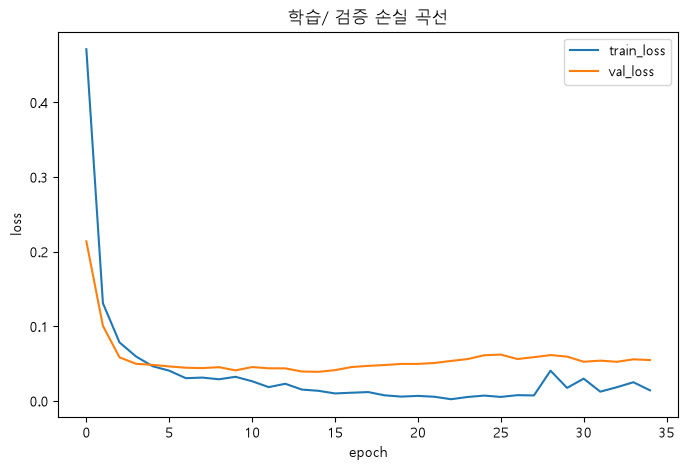

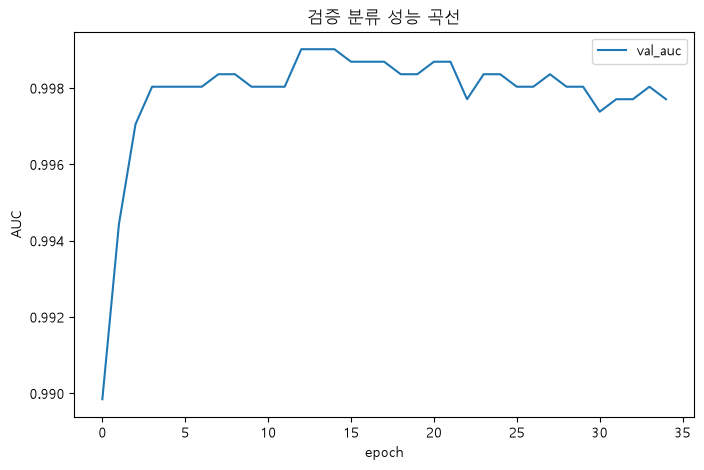

In [111]:
# Train / Valid Loss 학습곡선, Val AUC
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history["val_loss"],label= 'val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('학습/ 검증 손실 곡선')
plt.legend()
plt.show()




plt.figure(figsize=(8,5))
plt.plot(history["val_auc"],label= 'val_auc')
plt.xlabel('epoch')
plt.ylabel('AUC')
plt.title('검증 분류 성능 곡선')
plt.legend()
plt.show()

손실 곡선 : 학습은 줄어드는데 검증 손실은 줄어들지 않으면 과적합 신호로 본다.  

AUC 곡선 : 모델의 전반적인 분류 능력이 어떻게 변하는지 확인  
AUC 가 꾸준히 상승하면 클래스 간 구분 능력이 향상되고 있음


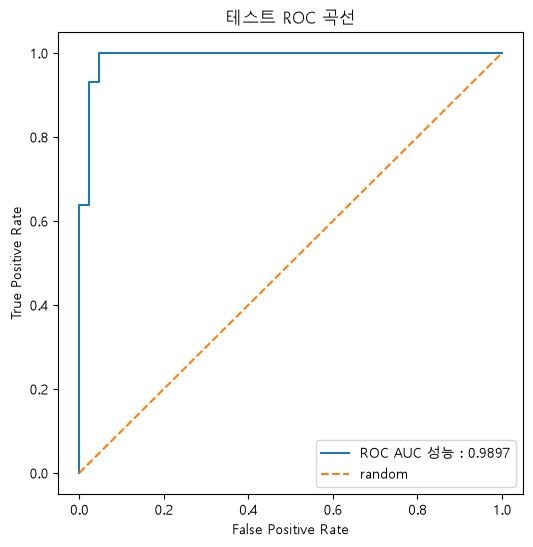

In [113]:
fpr, tpr, thr = roc_curve(y_true, y_prob)   # 실제값과 예측확률로 ROC 곡선 좌표 계산(FP 거짓-양성, TP 참-양성, 임계)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label= f"ROC AUC 성능 : {test_auc:.4f}") # 검증 AUC
plt.plot([0,1],[0,1], linestyle= "--", label= 'random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('테스트 ROC 곡선')
plt.legend()
plt.show()



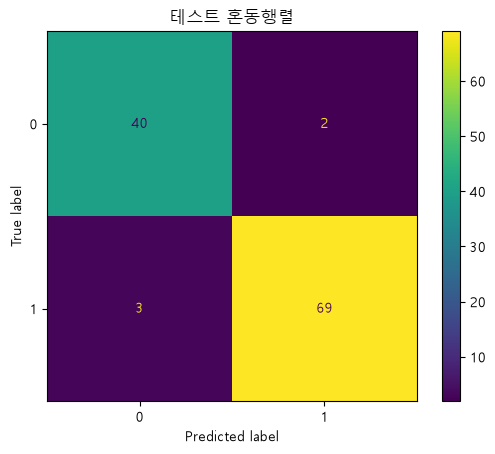

In [114]:
y_pred = (y_prob > 0.5).astype(int) # 모델의 예측 (0/1)
cm = confusion_matrix(y_true, y_pred) # 실제값과 예측값 비교 혼동행렬 계산
disp = ConfusionMatrixDisplay(confusion_matrix=cm) # 혼동행렬 시각화 객체
disp.plot()
plt.title('테스트 혼동행렬')
plt.show()

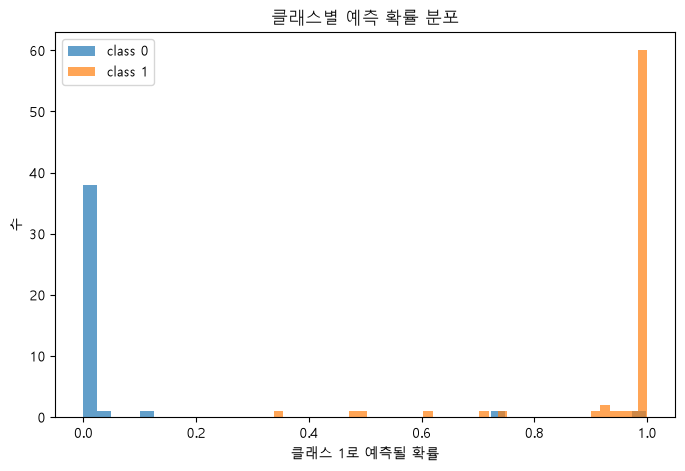

In [116]:
# 클래스별 예측 확률 분포
plt.figure(figsize=(8,5))

plt.hist(
    y_prob[y_true == 0], # 실제 클래스 0에 대한 예측 확률
    bins=40,
    alpha = 0.7,
    label = 'class 0'
)

plt.hist(
    y_prob[y_true == 1],
    bins=40,
    alpha = 0.7,
    label = 'class 1'
)

plt.xlabel('클래스 1로 예측될 확률')
plt.ylabel('수')
plt.title('클래스별 예측 확률 분포')
plt.legend()
plt.show()

두 클래스가 겹치는 부분은 약간 존재하긴 하지만 그렇게 크지 않음  
분류 경계가 명확한 편이고, 모델의 확신이 높은 편임

혼자서 공부하면서 적용해볼만한 사항
1. 은닉층 증축 설게 & 하이퍼파라미터 최적화
2. 최적화 함수 변경(Adam -> AdamW, NAdam, RAdam)
3. 스케일러 변경 (StandardScaler -> MinMaxScaler, RoburtScaler)
4. SMOTE (데이터 불균형)

5. 과적합 발생시 
    - Dropout / BatchNorm
    - Scheduler : lr 를 점진적으로 조절 (ReduceLROnPlateau 등)
    - Early Stopping
    - K-Fold Cross Validation